In [60]:
#####################################################
# Imports and Files IO
#####################################################

import pandas as pd
import os
import numpy as np 
from MDToolkit.math.smoothing import lowess 
from MDToolkit.math.differentiate import forward_finite_difference

files_dir = "/media/jrjoseph/Elements/projects/smaller_kcl_mos2_ls6/"
ensembles = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

file_names = [f"kcl_mos2_ensemble{ensemble}_15ns.csv" for ensemble in ensembles]

dfs = [pd.read_csv(os.path.join(files_dir, file_name)) for file_name in file_names]

df = pd.concat(dfs).groupby(level=0).mean()

print(df)

        timesteps             V  charge_translocation
0             0.0  0.000000e+00                   0.0
1          1000.0  1.507964e-04                   0.0
2          2000.0  3.015926e-04                   0.0
3          3000.0  4.523883e-04                   0.0
4          4000.0  6.031832e-04                   0.0
...           ...           ...                   ...
14998  14996000.0 -6.031832e-04                   6.1
14999  14997000.0 -4.523883e-04                   6.1
15000  14998000.0 -3.015926e-04                   6.1
15001  14999000.0 -1.507964e-04                   6.1
15002  15000000.0 -8.817457e-17                   6.1

[15003 rows x 3 columns]


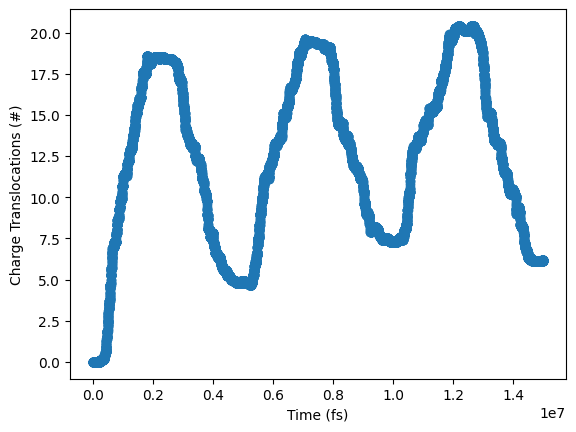

In [68]:
import matplotlib.pyplot as plt

plt.scatter(df["timesteps"], df["charge_translocation"])
plt.xlabel("Time (fs)")
plt.ylabel("Charge Translocations (#)")
plt.show()

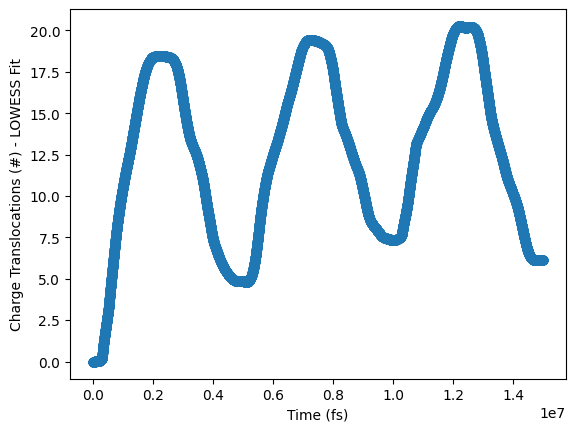

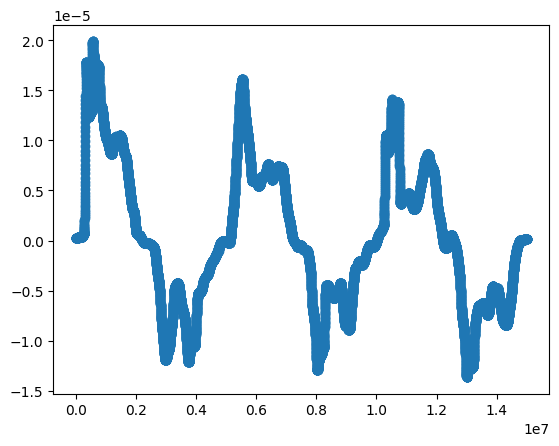

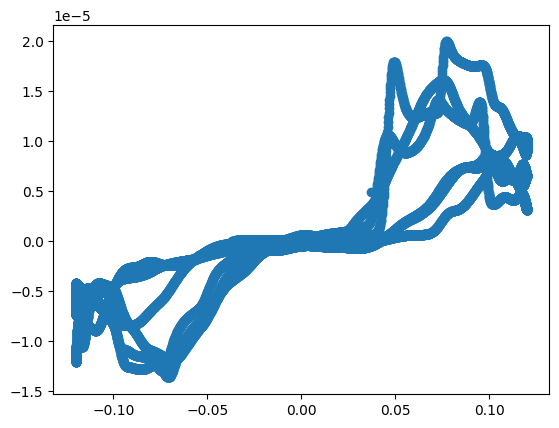

In [ ]:


x, y = lowess(df["timesteps"], df["charge_translocation"], window=500)

plt.scatter(x, y)
plt.xlabel("Time (fs)")
plt.ylabel("Charge Translocations (#) - LOWESS Fit")
plt.show()

dydx = forward_finite_difference(np.array(x), np.array(y))

plt.scatter(x, dydx)
plt.xlabel("Time (fs)")
plt.ylabel("Ionic Current (arb. units)")
plt.show()

plt.scatter(df["V"], dydx)
plt.xlabel("Applied Electric Field (V/Å)")
plt.ylabel("Ionic Current (arb. units)")
plt.show()

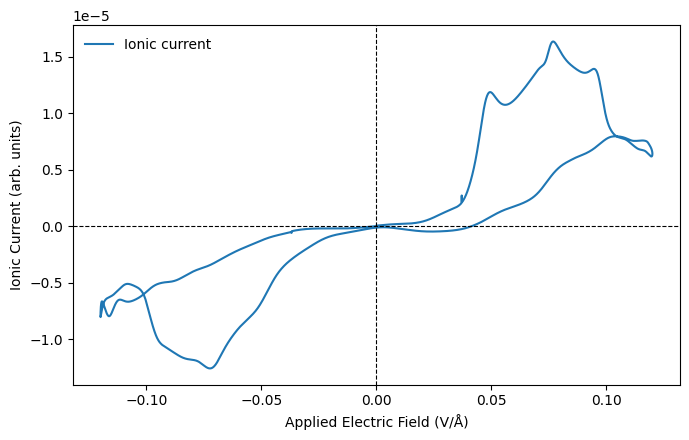

In [63]:
split_idxs = np.where(np.diff(x) == 0)[0]
idxs = [idx + 1 for idx in split_idxs]

x_splits = np.split(x, idxs)
dydx_splits = np.split(dydx, idxs)

dydx_split_mean = np.mean(dydx_splits, axis = 0)
V = np.array(df["V"])
V_split = np.split(V, idxs)

plt.figure(figsize=(7, 4.5))

plt.plot(
    V_split[0],
    dydx_split_mean,
    linewidth=1.5,
    label="Ionic current"
)

# Zero reference lines
plt.axhline(
    0,
    color="black",
    linewidth=0.8,
    linestyle="--"
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8,
    linestyle="--"
)

plt.xlabel("Applied Electric Field (V/Å)")
plt.ylabel("Ionic Current (arb. units)")

plt.legend(frameon=False)

plt.tight_layout()
plt.show()